In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import random
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from PIL import Image
from sklearn.metrics import average_precision_score
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


# =============================================================================
# CONFIGURATION
# =============================================================================

class Config:
    batch_size: int = 90
    num_workers: int = 2

    dobs: int = 1
    henc: int = 32
    hpre: int = 32
    dstc: int = 8
    steps: int = 4

    std_coeff: float = 10.0
    cov_coeff: float = 100.0

    lr: float = 1e-3
    epochs: int = 30

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 1
    log_every: int = 1
    save_every: int = 10

    map_size: int = 8
    seq_len: int = 6
    img_size: int = 32

    train_data_dir: str = "/kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.04.00/neurofinder.04.00"
    val_data_dir: str = "/kaggle/input/datasets/mokarbalaee/neurofinder-mini/neurofinder.04.01/neurofinder.04.01"


# =============================================================================
# UTILITIES
# =============================================================================

def setup_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def init_module_weights(m, std: float = 0.02):
    if isinstance(m, (nn.Conv2d, nn.Conv3d, nn.ConvTranspose2d, nn.ConvTranspose3d, nn.Linear)):
        nn.init.trunc_normal_(m.weight, std=std)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


# =============================================================================
# TEMPORAL BATCH MIXIN
# =============================================================================

class TemporalBatchMixin:
    def _forward(self, x):
        raise NotImplementedError

    def forward(self, x):
        assert x.ndim in [4, 5], "Only 4D or 5D tensors supported"
        if x.ndim == 5:
            b = x.shape[0]
            x = rearrange(x, "b c t h w -> (b t) c h w")
            out = self._forward(x)
            out = rearrange(out, "(b t) c h w -> b c t h w", b=b)
            return out
        return self._forward(x)


# =============================================================================
# DATASET
# =============================================================================

def load_neurofinder_frames(data_dir: str, img_size: int):
    img_dir = Path(data_dir) / "images"
    paths = sorted(img_dir.glob("*.tiff"))
    frames = []
    for p in paths:
        img = np.array(Image.open(p).resize((img_size, img_size), Image.BILINEAR)).astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        frames.append(img)
    return np.stack(frames)


def build_soma_mask(data_dir: str, img_size: int, map_size: int, n_frames: int):
    regions_path = Path(data_dir) / "regions" / "regions.json"
    with open(regions_path) as f:
        regions = json.load(f)

    with open(Path(data_dir) / "images" / "image00000.tiff", "rb") as f:
        orig = np.array(Image.open(f))
    orig_h, orig_w = orig.shape

    mask = np.zeros((map_size, map_size), dtype=np.float32)
    for region in regions:
        coords = np.array(region["coordinates"])
        cx = coords[:, 0].mean() / orig_w
        cy = coords[:, 1].mean() / orig_h
        px = int(cx * map_size)
        py = int(cy * map_size)
        px = min(px, map_size - 1)
        py = min(py, map_size - 1)
        mask[py, px] = 1.0

    return np.stack([mask] * n_frames)


class NeurofinderDataset(Dataset):
    def __init__(self, data_dir: str, seq_len: int = 10, img_size: int = 128, map_size: int = 8):
        self.seq_len = seq_len
        frames = load_neurofinder_frames(data_dir, img_size)
        self.frames = frames
        self.n_frames = len(frames)

        soma_seq = build_soma_mask(data_dir, img_size, map_size, self.n_frames)
        self.soma_masks = soma_seq

        self.indices = [
            i for i in range(0, self.n_frames - seq_len, seq_len)
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.seq_len

        video = self.frames[start:end]
        video = torch.from_numpy(video).unsqueeze(0).float()

        soma = self.soma_masks[start:end]
        soma = torch.from_numpy(soma).float()

        return {"video": video, "soma_mask": soma}


# =============================================================================
# ARCHITECTURES
# =============================================================================

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet5(TemporalBatchMixin, nn.Module):
    def __init__(self, in_d, h_d, out_d, s1=1, s2=1, s3=1, avg_pool=False):
        super().__init__()
        self.avg_pool = avg_pool
        self.conv1 = nn.Conv2d(in_d, h_d, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(h_d)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = ResidualBlock(h_d, h_d, stride=s1)
        self.layer2 = ResidualBlock(h_d, h_d * 2, stride=s2)
        self.layer3 = ResidualBlock(h_d * 2, out_d, stride=s3)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) if avg_pool else nn.Identity()

    def _forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        if self.avg_pool:
            out = out.flatten(1)
        return out


class ResUNet(TemporalBatchMixin, nn.Module):
    def __init__(self, in_d, h_d, out_d, is_rnn=False):
        super().__init__()
        self.is_rnn = is_rnn
        self.conv1 = nn.Conv2d(in_d, h_d, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(h_d)
        self.relu = nn.ReLU(inplace=True)

        self.enc1 = ResidualBlock(h_d, h_d, stride=1)
        self.enc2 = ResidualBlock(h_d, 2 * h_d, stride=2)
        self.enc3 = ResidualBlock(2 * h_d, 4 * h_d, stride=2)
        self.bott = ResidualBlock(4 * h_d, 8 * h_d, stride=2)

        self.up3 = nn.ConvTranspose2d(8 * h_d, 4 * h_d, 2, 2)
        self.dec3 = ResidualBlock(8 * h_d, 4 * h_d, stride=1)
        self.up2 = nn.ConvTranspose2d(4 * h_d, 2 * h_d, 2, 2)
        self.dec2 = ResidualBlock(4 * h_d, 2 * h_d, stride=1)
        self.up1 = nn.ConvTranspose2d(2 * h_d, 1 * h_d, 2, 2)
        self.dec1 = ResidualBlock(2 * h_d, 1 * h_d, stride=1)
        self.head = nn.Conv2d(h_d, out_d, 1)

    @staticmethod
    def _match_size(x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
        return x

    def _forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        s1 = self.enc1(x0)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        b = self.bott(s3)

        d3 = self._match_size(self.up3(b), s3)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))
        d2 = self._match_size(self.up2(d3), s2)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))
        d1 = self._match_size(self.up1(d2), s1)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))
        return self.head(d1)


class StateOnlyPredictor(nn.Module):
    def __init__(self, predictor, context_length=2):
        super().__init__()
        self.predictor = predictor
        self.is_rnn = predictor.is_rnn
        self.context_length = context_length

    def forward(self, x, a=None):
        prev_state = x[:, :, :-1]
        next_state = x[:, :, 1:]
        combined = torch.cat((prev_state, next_state), dim=1)
        return self.predictor(combined)


class Projector(nn.Module):
    def __init__(self, mlp_spec):
        super().__init__()
        layers = []
        f = list(map(int, mlp_spec.split("-")))
        for i in range(len(f) - 2):
            layers.extend([nn.Linear(f[i], f[i + 1]), nn.BatchNorm1d(f[i + 1]), nn.ReLU(True)])
        layers.append(nn.Linear(f[-2], f[-1], bias=False))
        self.net = nn.Sequential(*layers)
        self.out_dim = f[-1]

    def forward(self, x):
        return self.net(x)


class ImageDecoder(TemporalBatchMixin, nn.Module):
    def __init__(self, in_dim, out_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_dim, hidden_dim, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_dim, 3, 1, 1),
        )
        self.apply(init_module_weights)

    def _forward(self, x):
        return self.net(x)


class conv3d2(nn.Sequential):
    def __init__(self, in_d, h_d, out_d, tk, ts, sk, ss, pad):
        super().__init__(
            nn.Conv3d(in_d, h_d, (tk, sk, sk), (1, 1, 1), pad),
            nn.ReLU(),
            nn.Conv3d(h_d, out_d, (tk, sk, sk), (ts, ss, ss), pad),
        )
        self.apply(init_module_weights)
        if pad == "valid":
            self.t_shift = 2 * tk - 1
        elif pad == "same":
            self.t_shift = 2 * (tk - 1)


class SomaDetHead(nn.Module):
    def __init__(self, in_d, h_d, map_size=8):
        super().__init__()
        self.map_size = map_size
        self.head = nn.Sequential(conv3d2(in_d, h_d, 1, 1, 1, 3, 1, "same"))
        self.apply(init_module_weights)

    def forward(self, x):
        x = [F.adaptive_avg_pool2d(x[:, :, t], (self.map_size, self.map_size))
             for t in range(x.shape[2])]
        x = torch.stack(x, 2)
        x = self.head(x).squeeze(1)
        return torch.sigmoid(x)

    @torch.no_grad()
    def score(self, preds, targets):
        scores = []
        for T in range(len(preds) - 1):
            x = preds[T]
            x = [F.adaptive_avg_pool2d(x[:, :, t], (self.map_size, self.map_size))
                 for t in range(x.shape[2])]
            x = torch.stack(x, 2)
            x = self.head(x).squeeze(1)
            y = targets[:, T:]
            x = x[:, T:]
            try:
                ap = average_precision_score(
                    y.flatten().detach().long().cpu().numpy(),
                    x.flatten().detach().cpu().numpy(),
                    average="weighted",
                )
            except ValueError:
                ap = 0.0
            scores.append(ap)
        return scores


# =============================================================================
# LOSSES
# =============================================================================

class HingeStdLoss(nn.Module):
    def __init__(self, std_margin: float = 1.0):
        super().__init__()
        self.std_margin = std_margin

    def forward(self, x):
        x = x - x.mean(dim=0, keepdim=True)
        std = torch.sqrt(x.var(dim=0) + 0.0001)
        return torch.mean(F.relu(self.std_margin - std))


class CovarianceLoss(nn.Module):
    def off_diagonal(self, x):
        n, m = x.shape
        assert n == m
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

    def forward(self, x):
        batch_size = x.shape[0]
        x = x - x.mean(dim=0, keepdim=True)
        cov = (x.T @ x) / (batch_size - 1)
        return self.off_diagonal(cov).pow(2).mean()


class VCLoss(nn.Module):
    def __init__(self, std_coeff, cov_coeff, proj=None):
        super().__init__()
        self.std_coeff = std_coeff
        self.cov_coeff = cov_coeff
        self.proj = nn.Identity() if proj is None else proj
        self.std_loss_fn = HingeStdLoss(std_margin=1.0)
        self.cov_loss_fn = CovarianceLoss()

    def forward(self, x, actions=None):
        x = x.transpose(0, 1).flatten(1).transpose(0, 1)
        fx = self.proj(x)
        std_loss = self.std_loss_fn(fx)
        cov_loss = self.cov_loss_fn(fx)
        loss = self.std_coeff * std_loss + self.cov_coeff * cov_loss
        total_unweighted = std_loss + cov_loss
        loss_dict = {"std_loss": std_loss.item(), "cov_loss": cov_loss.item()}
        return loss, total_unweighted, loss_dict


class SquareLossSeq(nn.Module):
    def __init__(self, proj=None):
        super().__init__()
        self.proj = nn.Identity() if proj is None else proj

    def forward(self, state, predi):
        state = self.proj(state.transpose(0, 1).flatten(1).transpose(0, 1))
        predi = self.proj(predi.transpose(0, 1).flatten(1).transpose(0, 1))
        return F.mse_loss(state, predi)


# =============================================================================
# JEPA
# =============================================================================

class JEPA(nn.Module):
    def __init__(self, encoder, aencoder, predictor, regularizer, predcost):
        super().__init__()
        self.encoder = encoder
        self.action_encoder = aencoder
        self.predictor = predictor
        self.regularizer = regularizer
        self.predcost = predcost
        self.single_unroll = getattr(self.predictor, "is_rnn", False)

    def unroll(self, observations, actions=None, nsteps=1, unroll_mode="parallel",
               ctxt_window_time=1, compute_loss=True, return_all_steps=False):
        state = self.encoder(observations)
        context_length = getattr(self.predictor, "context_length", 0)

        if compute_loss:
            rloss, rloss_unweight, rloss_dict = self.regularizer(state, actions)
            ploss = 0.0
        else:
            rloss = rloss_unweight = rloss_dict = ploss = None

        actions_encoded = self.action_encoder(actions) if actions is not None else None
        all_steps = [] if return_all_steps else None

        if unroll_mode == "parallel":
            predicted_states = state
            for _ in range(nsteps):
                predicted_states = self.predictor(predicted_states, actions_encoded)[:, :, :-1]
                if return_all_steps:
                    all_steps.append(predicted_states)
                predicted_states = torch.cat((state[:, :, :context_length], predicted_states), dim=2)
                if compute_loss:
                    ploss += self.predcost(state, predicted_states) / nsteps

        elif unroll_mode == "autoregressive":
            if actions is not None and nsteps > actions.size(2):
                raise ValueError(f"nsteps ({nsteps}) > action length ({actions.size(2)})")
            effective_ctxt = 1 if self.single_unroll else ctxt_window_time
            predicted_states = state[:, :, :effective_ctxt]
            for i in range(nsteps):
                context_states = predicted_states[:, :, -effective_ctxt:]
                context_actions = (actions_encoded[:, :, max(0, i + 1 - effective_ctxt):i + 1]
                                   if actions_encoded is not None else None)
                pred_step = self.predictor(context_states, context_actions)[:, :, -1:]
                predicted_states = torch.cat([predicted_states, pred_step], dim=2)
                if return_all_steps:
                    all_steps.append(predicted_states.clone())
                if compute_loss:
                    ploss += self.predcost(pred_step, state[:, :, i + 1:i + 2]) / nsteps
        else:
            raise ValueError(f"Unknown unroll_mode: {unroll_mode}")

        if compute_loss:
            loss = rloss + ploss
            losses = (loss, rloss, rloss_unweight, rloss_dict, ploss)
        else:
            losses = None

        return (all_steps if return_all_steps else predicted_states), losses


class JEPAProbe(nn.Module):
    def __init__(self, jepa, head, hcost):
        super().__init__()
        self.jepa = jepa
        self.head = head
        self.hcost = hcost

    def forward(self, observations, targets):
        with torch.no_grad():
            state = self.jepa.encoder(observations)
        output = self.head(state.detach())
        return self.hcost(output, targets)


# =============================================================================
# EVALUATION
# =============================================================================

@torch.inference_mode()
def validation_loop(val_loader, jepa, detection_head, pixel_decoder, steps, device):
    jepa.eval()
    detection_head.eval()
    pixel_decoder.eval()

    metrics = {k: [] for k in ["val/recon_loss", "val/det_loss"]}
    for batch in tqdm(val_loader, desc="Val", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        x = batch["video"]
        soma_map = batch["soma_mask"]

        recon_loss = pixel_decoder(x, x)
        det_loss = detection_head(x, soma_map)
        metrics["val/recon_loss"].append(float(recon_loss.item()))
        metrics["val/det_loss"].append(float(det_loss.item()))

        T = x.shape[2]
        preds, _ = jepa.unroll(x, None, nsteps=T - 2, unroll_mode="parallel",
                               compute_loss=False, return_all_steps=True)
        scores = detection_head.head.score(preds, soma_map[:, 2:])
        for s, score in enumerate(scores):
            metrics.setdefault(f"AP_{s}", []).append(float(score))

    jepa.train()
    detection_head.train()
    pixel_decoder.train()
    return {k: float(np.mean(v)) for k, v in metrics.items()}


# =============================================================================
# TRAINING
# =============================================================================

def train(cfg: Config):
    device = torch.device(cfg.device)
    setup_seed(cfg.seed)

    train_set = NeurofinderDataset(
        cfg.train_data_dir, seq_len=cfg.seq_len,
        img_size=cfg.img_size, map_size=cfg.map_size
    )
    val_set = NeurofinderDataset(
        cfg.val_data_dir, seq_len=cfg.seq_len,
        img_size=cfg.img_size, map_size=cfg.map_size
    )
    train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False,
                            num_workers=cfg.num_workers, pin_memory=True)

    print(f"Train: {len(train_set)} | Val: {len(val_set)} | Device: {device}")

    encoder = ResNet5(cfg.dobs, cfg.henc, cfg.dstc)
    predictor_model = ResUNet(2 * cfg.dstc, cfg.hpre, cfg.dstc)
    predictor = StateOnlyPredictor(predictor_model, context_length=2)
    projector = Projector(f"{cfg.dstc}-{cfg.dstc*4}-{cfg.dstc*4}")
    regularizer = VCLoss(cfg.std_coeff, cfg.cov_coeff, proj=projector)
    ploss = SquareLossSeq(projector)
    jepa = JEPA(encoder, encoder, predictor, regularizer, ploss).to(device)

    decoder = ImageDecoder(cfg.dstc, cfg.dobs, hidden_dim=16)
    dethead = SomaDetHead(cfg.dstc, cfg.hpre, map_size=cfg.map_size)
    pixel_decoder = JEPAProbe(jepa, decoder, nn.MSELoss()).to(device)
    detection_head = JEPAProbe(jepa, dethead, nn.BCELoss()).to(device)

    enc_params = sum(p.numel() for p in encoder.parameters())
    pre_params = sum(p.numel() for p in predictor.parameters())
    print(f"Encoder params: {enc_params:,} | Predictor params: {pre_params:,}")

    jepa.train()
    detection_head.train()
    pixel_decoder.train()

    optimizer = Adam([
        {"params": jepa.parameters(), "lr": cfg.lr},
        {"params": pixel_decoder.head.parameters(), "lr": cfg.lr / 10},
        {"params": detection_head.head.parameters(), "lr": cfg.lr},
    ])

    global_step = 0
    for epoch in range(cfg.epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}
            x = batch["video"]
            soma_map = batch["soma_mask"]

            optimizer.zero_grad()
            _, (jepa_loss, regl, _, regldict, pl) = jepa.unroll(
                x, None, nsteps=cfg.steps, unroll_mode="parallel",
                compute_loss=True, return_all_steps=False,
            )
            recon_loss = pixel_decoder(x, x)
            det_loss = detection_head(x, soma_map)
            total_loss = jepa_loss + recon_loss + det_loss

            total_loss.backward()
            optimizer.step()

            pbar.set_postfix({
                "loss": f"{jepa_loss.item():.4f}",
                "vc": f"{regl.item():.4f}",
                "pred": f"{pl.item():.4f}",
            })
            global_step += 1

        if epoch % cfg.log_every == 0:
            val_logs = validation_loop(val_loader, jepa, detection_head,
                                       pixel_decoder, cfg.steps, device)
            print(f"\nEpoch {epoch}: val_recon={val_logs.get('val/recon_loss', 0):.4f} "
                  f"val_det={val_logs.get('val/det_loss', 0):.4f}")
            for k, v in val_logs.items():
                if k.startswith("AP_"):
                    print(f"  {k}={v:.4f}")

        if epoch % cfg.save_every == 0:
            torch.save(jepa.state_dict(), f"jepa_epoch{epoch}.pt")

    print("Training complete!")
    return jepa, pixel_decoder, detection_head


Epoch 0: 100%|██████████| 8/8 [00:09<00:00,  1.16s/it, jepa=6.1909, recon=0.1737, det=0.5425]


Epoch 0 | jepa=6.5103 recon=0.1817 det=0.6279 dice=0.9508 miou=0.9062


Epoch 1: 100%|██████████| 8/8 [00:10<00:00,  1.31s/it, jepa=5.7994, recon=0.1521, det=0.3465]


Epoch 1 | jepa=5.9503 recon=0.1592 det=0.4207 dice=0.9508 miou=0.9062


Epoch 2: 100%|██████████| 8/8 [00:09<00:00,  1.19s/it, jepa=5.5992, recon=0.1338, det=0.3336]


...

Epoch 27 | jepa=3.1784 recon=0.0226 det=0.0857 dice=0.9828 miou=0.9661


Epoch 28: 100%|██████████| 8/8 [00:08<00:00,  1.09s/it, jepa=3.0811, recon=0.0246, det=0.0782]


Epoch 28 | jepa=3.1132 recon=0.0240 det=0.0804 dice=0.9880 miou=0.9762


Epoch 29: 100%|██████████| 8/8 [00:08<00:00,  1.09s/it, jepa=2.9986, recon=0.0241, det=0.0732]


Epoch 29 | jepa=3.0344 recon=0.0248 det=0.0747 dice=0.9868 miou=0.9739


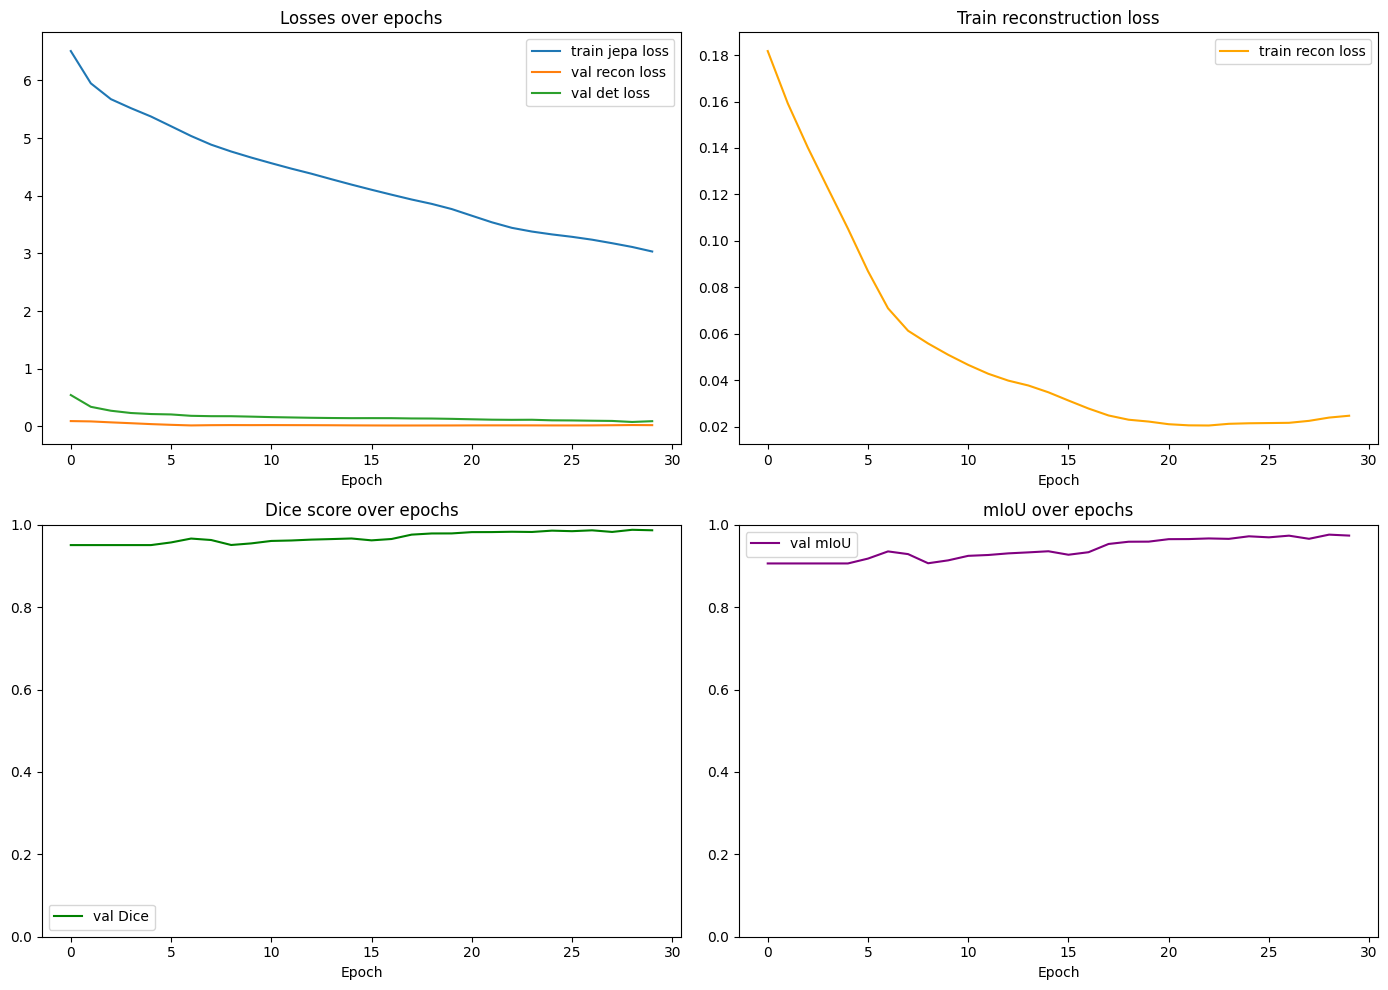

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def compute_dice_miou(pred_mask, gt_mask, threshold=0.5):
    pred_bin = (pred_mask > threshold).float()
    gt_bin = (gt_mask > threshold).float()

    pred_flat = pred_bin.view(-1)
    gt_flat = gt_bin.view(-1)

    intersection = (pred_flat * gt_flat).sum()
    dice = (2 * intersection) / (pred_flat.sum() + gt_flat.sum() + 1e-8)

    union = (pred_flat + gt_flat - pred_flat * gt_flat).sum()
    miou = intersection / (union + 1e-8)

    return dice.item(), miou.item()


@torch.inference_mode()
def validation_loop_with_metrics(val_loader, jepa, detection_head, pixel_decoder, steps, device):
    jepa.eval()
    detection_head.eval()
    pixel_decoder.eval()

    metrics = {k: [] for k in ["val/recon_loss", "val/det_loss", "val/dice", "val/miou"]}

    for batch in tqdm(val_loader, desc="Val", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        x = batch["video"]
        soma_map = batch["soma_mask"]

        recon_loss = pixel_decoder(x, x)
        det_loss = detection_head(x, soma_map)
        metrics["val/recon_loss"].append(float(recon_loss.item()))
        metrics["val/det_loss"].append(float(det_loss.item()))

        with torch.no_grad():
            state = jepa.encoder(x)
        pred_mask = detection_head.head(state.detach())

        dice, miou = compute_dice_miou(pred_mask, soma_map)
        metrics["val/dice"].append(dice)
        metrics["val/miou"].append(miou)

    jepa.train()
    detection_head.train()
    pixel_decoder.train()

    return {k: float(np.mean(v)) for k, v in metrics.items()}


def train_with_metrics(cfg):
    device = torch.device(cfg.device)
    setup_seed(cfg.seed)

    train_set = NeurofinderDataset(
        cfg.train_data_dir, seq_len=cfg.seq_len,
        img_size=cfg.img_size, map_size=cfg.map_size
    )
    val_set = NeurofinderDataset(
        cfg.val_data_dir, seq_len=cfg.seq_len,
        img_size=cfg.img_size, map_size=cfg.map_size
    )
    train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False,
                            num_workers=cfg.num_workers, pin_memory=True)

    encoder = ResNet5(cfg.dobs, cfg.henc, cfg.dstc)
    predictor_model = ResUNet(2 * cfg.dstc, cfg.hpre, cfg.dstc)
    predictor = StateOnlyPredictor(predictor_model, context_length=2)
    projector = Projector(f"{cfg.dstc}-{cfg.dstc*4}-{cfg.dstc*4}")
    regularizer = VCLoss(cfg.std_coeff, cfg.cov_coeff, proj=projector)
    ploss = SquareLossSeq(projector)
    jepa = JEPA(encoder, encoder, predictor, regularizer, ploss).to(device)

    decoder = ImageDecoder(cfg.dstc, cfg.dobs, hidden_dim=16)
    dethead = SomaDetHead(cfg.dstc, cfg.hpre, map_size=cfg.map_size)
    pixel_decoder = JEPAProbe(jepa, decoder, nn.MSELoss()).to(device)
    detection_head = JEPAProbe(jepa, dethead, nn.BCELoss()).to(device)

    optimizer = Adam([
        {"params": jepa.parameters(), "lr": cfg.lr},
        {"params": pixel_decoder.head.parameters(), "lr": cfg.lr / 10},
        {"params": detection_head.head.parameters(), "lr": cfg.lr},
    ])

    history = {
        "jepa_loss": [], "recon_loss": [], "det_loss": [],
        "val_recon": [], "val_det": [], "val_dice": [], "val_miou": []
    }

    for epoch in range(cfg.epochs):
        jepa.train()
        detection_head.train()
        pixel_decoder.train()

        epoch_jepa, epoch_recon, epoch_det = [], [], []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}
            x = batch["video"]
            soma_map = batch["soma_mask"]

            optimizer.zero_grad()
            _, (jepa_loss, regl, _, regldict, pl) = jepa.unroll(
                x, None, nsteps=cfg.steps, unroll_mode="parallel",
                compute_loss=True, return_all_steps=False,
            )
            recon_loss = pixel_decoder(x, x)
            det_loss = detection_head(x, soma_map)
            total_loss = jepa_loss + recon_loss + det_loss
            total_loss.backward()
            optimizer.step()

            epoch_jepa.append(jepa_loss.item())
            epoch_recon.append(recon_loss.item())
            epoch_det.append(det_loss.item())

            pbar.set_postfix({
                "jepa": f"{jepa_loss.item():.4f}",
                "recon": f"{recon_loss.item():.4f}",
                "det": f"{det_loss.item():.4f}",
            })

        history["jepa_loss"].append(np.mean(epoch_jepa))
        history["recon_loss"].append(np.mean(epoch_recon))
        history["det_loss"].append(np.mean(epoch_det))

        val_logs = validation_loop_with_metrics(
            val_loader, jepa, detection_head, pixel_decoder, cfg.steps, device
        )
        history["val_recon"].append(val_logs["val/recon_loss"])
        history["val_det"].append(val_logs["val/det_loss"])
        history["val_dice"].append(val_logs["val/dice"])
        history["val_miou"].append(val_logs["val/miou"])

        print(f"Epoch {epoch} | jepa={history['jepa_loss'][-1]:.4f} "
              f"recon={history['recon_loss'][-1]:.4f} det={history['det_loss'][-1]:.4f} "
              f"dice={history['val_dice'][-1]:.4f} miou={history['val_miou'][-1]:.4f}")

    return jepa, pixel_decoder, detection_head, history


def plot_metrics(history):
    epochs = range(len(history["jepa_loss"]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, history["jepa_loss"], label="train jepa loss")
    axes[0, 0].plot(epochs, history["val_recon"], label="val recon loss")
    axes[0, 0].plot(epochs, history["val_det"], label="val det loss")
    axes[0, 0].set_title("Losses over epochs")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()

    axes[0, 1].plot(epochs, history["recon_loss"], label="train recon loss", color="orange")
    axes[0, 1].set_title("Train reconstruction loss")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()

    axes[1, 0].plot(epochs, history["val_dice"], label="val Dice", color="green")
    axes[1, 0].set_title("Dice score over epochs")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend()

    axes[1, 1].plot(epochs, history["val_miou"], label="val mIoU", color="purple")
    axes[1, 1].set_title("mIoU over epochs")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


cfg = Config()
torch.cuda.empty_cache()
jepa, pixel_decoder, detection_head, history = train_with_metrics(cfg)
plot_metrics(history)

In [13]:
torch.save(jepa, "model_full.pth")

In [14]:
model = torch.load("model_full.pth", weights_only=False)
model.eval()

JEPA(
  (encoder): ResNet5(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (layer1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (layer2): ResidualBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size